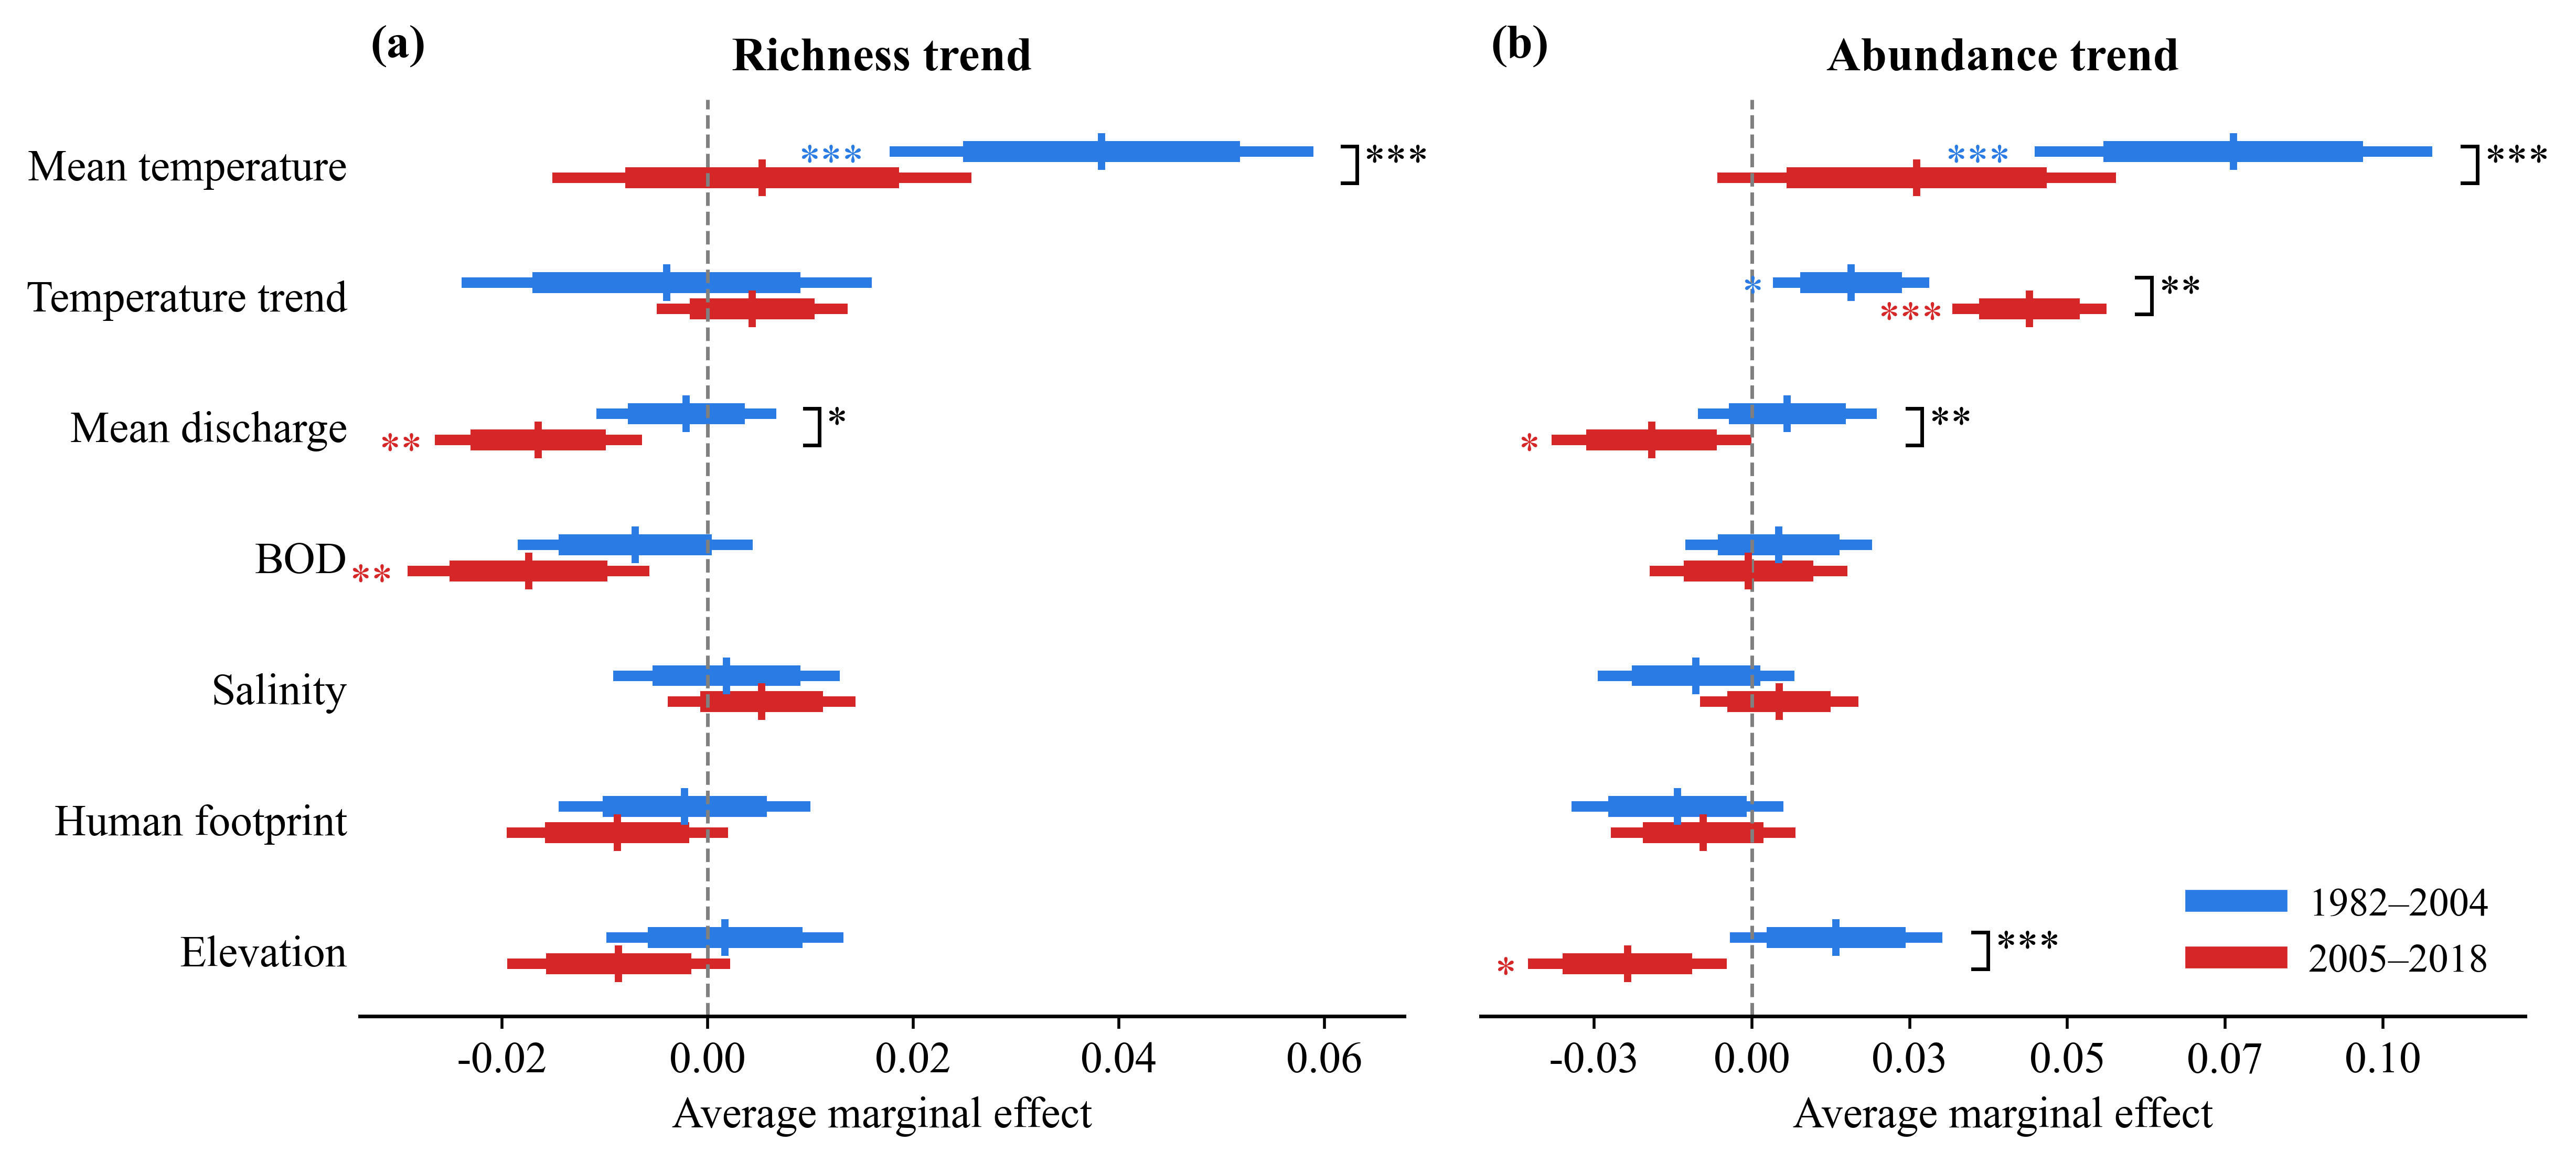

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

df_rich = pd.read_csv(
    r"D:\paper\outputdata\Phase-specific modelling of richness trends\Period_MarginalEffects_by_zone.csv"
)


df_abun = pd.read_csv(
    r"D:\paper\outputdata\Phase-specific modelling of abundance trends\Period_effects_by_zone_with_CI_Abundance_AME.csv"
)
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.linewidth": 1,
    "font.size": 12
})

EARLY_COLOR = "#2a7be4"
LATE_COLOR  = "#d62728"

W95 = 0.08
W80 = 0.16
Y_OFFSET = 0.10

Z95 = 1.96
Z80 = 1.28

order_vars = [
    "mean_temp",
    "sen_temp",
    "mean_Q",
    "mean_organic",
    "mean_salinity",
    "HFP_period",
    "elevation"
]

name_map = {
    "mean_temp":     "Mean temperature",
    "sen_temp":      "Temperature trend",
    "mean_Q":        "Mean discharge",
    "mean_organic":  "BOD",
    "mean_salinity": "Salinity",
    "HFP_period":    "Human footprint",
    "elevation":     "Elevation",
}

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

def plot_all_panel(ax, df_effects, panel_label, title):

    sub_z = df_effects[df_effects["Zone"] == "All"]

    vals = np.abs(sub_z[
        ["Early_CI95_L", "Early_CI95_U",
         "Late_CI95_L",  "Late_CI95_U"]
    ].values.flatten())

    M = max(np.round(vals.max() + 0.015, 2), 0.06)

    for i, v in enumerate(order_vars):
        y0 = i
        sub_v = sub_z[sub_z["Factor"] == v]
        if sub_v.empty:
            continue
        for eff, lo95, up95, dy, color, pval in [
            (sub_v["Early_Effect"].values[0],
             sub_v["Early_CI95_L"].values[0],
             sub_v["Early_CI95_U"].values[0],
             -Y_OFFSET, EARLY_COLOR,
             sub_v["Early_p"].values[0]),

            (sub_v["Late_Effect"].values[0],
             sub_v["Late_CI95_L"].values[0],
             sub_v["Late_CI95_U"].values[0],
             +Y_OFFSET, LATE_COLOR,
             sub_v["Late_p"].values[0])
        ]:

            yy = y0 + dy

            se = (up95 - eff) / Z95
            lo80 = eff - Z80 * se
            up80 = eff + Z80 * se
            ax.add_patch(Rectangle(
                (lo95, yy - W95/2),
                up95 - lo95, W95,
                facecolor=color, linewidth=0
            ))
            ax.add_patch(Rectangle(
                (lo80, yy - W80/2),
                up80 - lo80, W80,
                facecolor=color, linewidth=0
            ))
            ax.plot(
                eff, yy, marker="|",
                color=color,
                markersize=10,
                markeredgewidth=2,
                zorder=10
            )
            ax.text(
                lo95 - 0.06*(up95 - lo95),
                yy + 0.1,
                p_to_star(pval),
                color=color,
                ha="right",
                va="center",
                fontsize=12
            )

        p_delta = sub_v["Delta_p"].values[0]
        star_d = p_to_star(p_delta)

        if star_d:
            xmax = max(
                sub_v["Early_CI95_U"].values[0],
                sub_v["Late_CI95_U"].values[0]
            )
            dx = 0.03 * (2 * M)

            ax.plot(
                [xmax + dx, xmax + dx],
                [y0 - Y_OFFSET - W95/2, y0 + Y_OFFSET + W95/2],
                color="black", lw=1
            )
            ax.plot(
                [xmax + dx - 0.01*(2*M), xmax + dx],
                [y0 - Y_OFFSET - W95/2]*2,
                color="black", lw=1
            )
            ax.plot(
                [xmax + dx - 0.01*(2*M), xmax + dx],
                [y0 + Y_OFFSET + W95/2]*2,
                color="black", lw=1
            )

            ax.text(
                xmax + dx * 1.15,
                y0,
                star_d,
                va="center",
                ha="left",
                fontsize=12
            )
    ax.axvline(0, color="gray", linestyle="--", lw=1)
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.text(
        0.01, 1.08, panel_label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top",
        ha="left"
    )

    ax.set_xlabel("Average marginal effect", fontsize=12)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", length=0)

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4.6),
    dpi=500,
    sharey=True
)

plot_all_panel(
    axes[0], df_rich,
    panel_label="(a)",
    title="Richness trend"
)

plot_all_panel(
    axes[1], df_abun,
    panel_label="(b)",
    title="Abundance trend"
)

axes[0].set_yticks(np.arange(len(order_vars)))
axes[0].set_yticklabels([name_map[v] for v in order_vars])
axes[0].invert_yaxis()
legend_elems = [
    Line2D([0], [0], color=EARLY_COLOR, lw=6, label="1982–2004"),
    Line2D([0], [0], color=LATE_COLOR,  lw=6, label="2005–2018"),
]

axes[1].legend(
    handles=legend_elems,
    loc="lower right",
    frameon=False,
    fontsize=11
)
plt.tight_layout()
plt.savefig(
    r"C:\Users\Lenovo\Desktop\extendFig9.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()

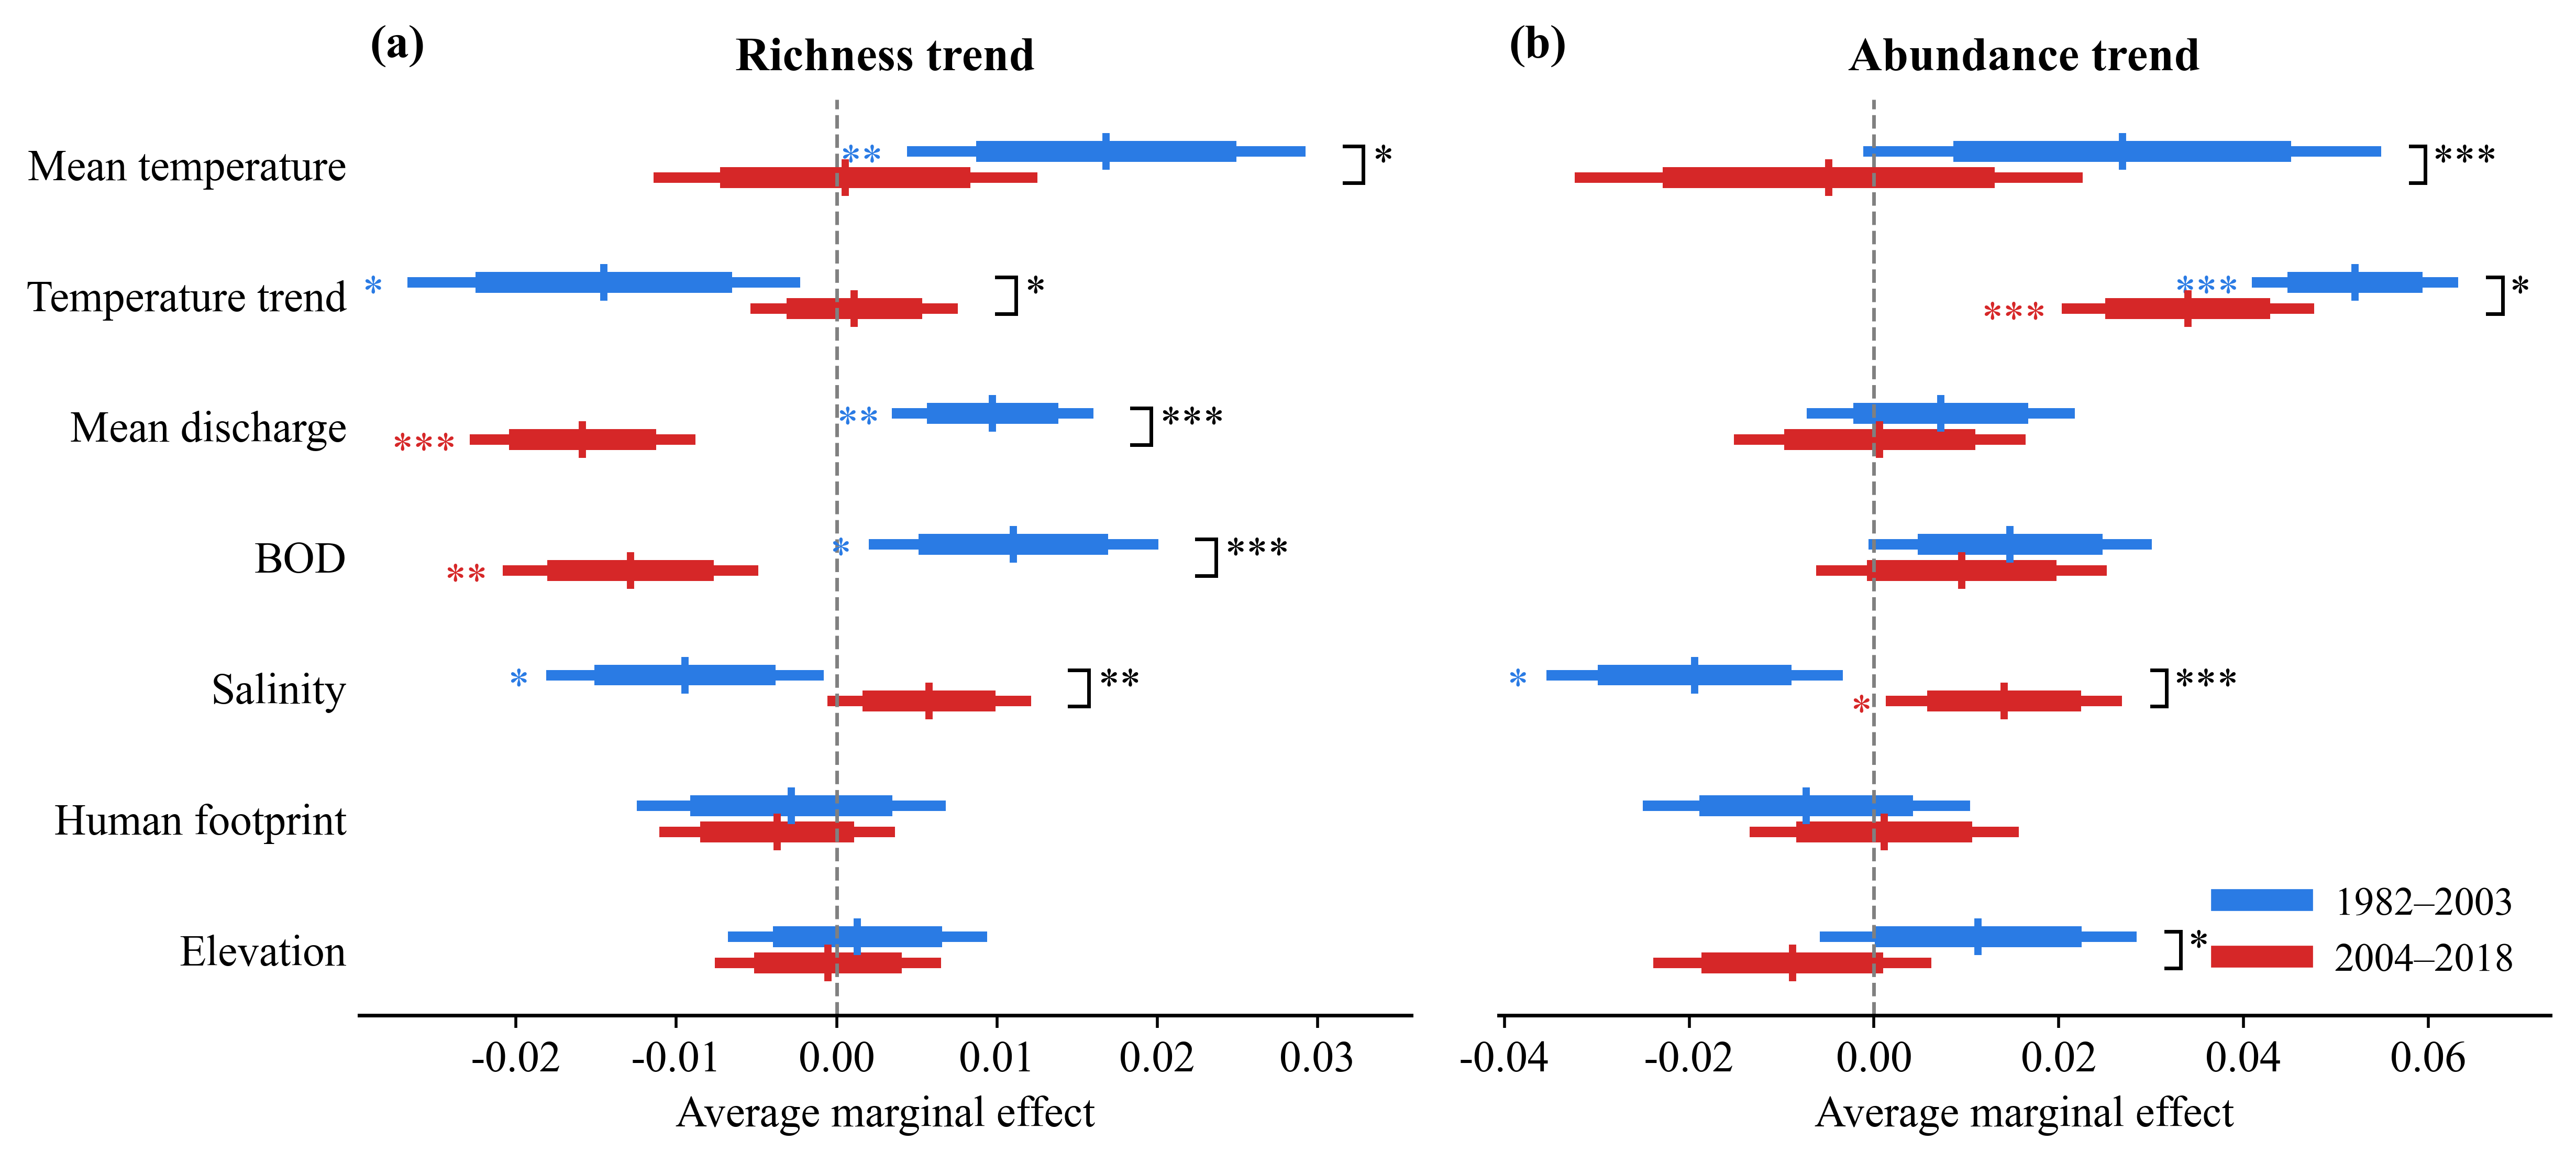

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

df_rich = pd.read_csv(
    r"D:\paper\outputdata\Phase-specific modelling of 2003\Period_MarginalEffects_All.csv"
)

df_abun = pd.read_csv(
    r"D:\paper\outputdata\Phase-specific modelling of 2003\Period_effects_All_Abundance_AME.csv"
)
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.linewidth": 1,
    "font.size": 12
})

EARLY_COLOR = "#2a7be4"
LATE_COLOR  = "#d62728"

W95 = 0.08
W80 = 0.16
Y_OFFSET = 0.10

Z95 = 1.96
Z80 = 1.28

order_vars = [
    "mean_temp",
    "sen_temp",
    "mean_Q",
    "mean_organic",
    "mean_salinity",
    "HFP_period",
    "elevation"
]

name_map = {
    "mean_temp":     "Mean temperature",
    "sen_temp":      "Temperature trend",
    "mean_Q":        "Mean discharge",
    "mean_organic":  "BOD",
    "mean_salinity": "Salinity",
    "HFP_period":    "Human footprint",
    "elevation":     "Elevation",
}

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

def plot_all_panel(ax, df_effects, panel_label, title):

    sub_z = df_effects[df_effects["Zone"] == "All"]

    vals = np.abs(sub_z[
        ["Early_CI95_L", "Early_CI95_U",
         "Late_CI95_L",  "Late_CI95_U"]
    ].values.flatten())

    M = max(np.round(vals.max() + 0.015, 2), 0.06)

    for i, v in enumerate(order_vars):
        y0 = i
        sub_v = sub_z[sub_z["Factor"] == v]
        if sub_v.empty:
            continue
        for eff, lo95, up95, dy, color, pval in [
            (sub_v["Early_Effect"].values[0],
             sub_v["Early_CI95_L"].values[0],
             sub_v["Early_CI95_U"].values[0],
             -Y_OFFSET, EARLY_COLOR,
             sub_v["Early_p"].values[0]),

            (sub_v["Late_Effect"].values[0],
             sub_v["Late_CI95_L"].values[0],
             sub_v["Late_CI95_U"].values[0],
             +Y_OFFSET, LATE_COLOR,
             sub_v["Late_p"].values[0])
        ]:

            yy = y0 + dy

            se = (up95 - eff) / Z95
            lo80 = eff - Z80 * se
            up80 = eff + Z80 * se
            ax.add_patch(Rectangle(
                (lo95, yy - W95/2),
                up95 - lo95, W95,
                facecolor=color, linewidth=0
            ))
            ax.add_patch(Rectangle(
                (lo80, yy - W80/2),
                up80 - lo80, W80,
                facecolor=color, linewidth=0
            ))
            ax.plot(
                eff, yy, marker="|",
                color=color,
                markersize=10,
                markeredgewidth=2,
                zorder=10
            )
            ax.text(
                lo95 - 0.06*(up95 - lo95),
                yy + 0.1,
                p_to_star(pval),
                color=color,
                ha="right",
                va="center",
                fontsize=12
            )

        p_delta = sub_v["Delta_p"].values[0]
        star_d = p_to_star(p_delta)

        if star_d:
            xmax = max(
                sub_v["Early_CI95_U"].values[0],
                sub_v["Late_CI95_U"].values[0]
            )
            dx = 0.03 * (2 * M)

            ax.plot(
                [xmax + dx, xmax + dx],
                [y0 - Y_OFFSET - W95/2, y0 + Y_OFFSET + W95/2],
                color="black", lw=1
            )
            ax.plot(
                [xmax + dx - 0.01*(2*M), xmax + dx],
                [y0 - Y_OFFSET - W95/2]*2,
                color="black", lw=1
            )
            ax.plot(
                [xmax + dx - 0.01*(2*M), xmax + dx],
                [y0 + Y_OFFSET + W95/2]*2,
                color="black", lw=1
            )

            ax.text(
                xmax + dx * 1.15,
                y0,
                star_d,
                va="center",
                ha="left",
                fontsize=12
            )
    ax.axvline(0, color="gray", linestyle="--", lw=1)
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.text(
        0.01, 1.08, panel_label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top",
        ha="left"
    )

    ax.set_xlabel("Average marginal effect", fontsize=12)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", length=0)

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4.6),
    dpi=500,
    sharey=True
)

plot_all_panel(
    axes[0], df_rich,
    panel_label="(a)",
    title="Richness trend"
)

plot_all_panel(
    axes[1], df_abun,
    panel_label="(b)",
    title="Abundance trend"
)

axes[0].set_yticks(np.arange(len(order_vars)))
axes[0].set_yticklabels([name_map[v] for v in order_vars])
axes[0].invert_yaxis()
legend_elems = [
    Line2D([0], [0], color=EARLY_COLOR, lw=6, label="1982–2003"),
    Line2D([0], [0], color=LATE_COLOR,  lw=6, label="2004–2018"),
]

axes[1].legend(
    handles=legend_elems,
    loc="lower right",
    frameon=False,
    fontsize=11
)
plt.tight_layout()
plt.savefig(
    r"C:\Users\Lenovo\Desktop\extendFig10.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()

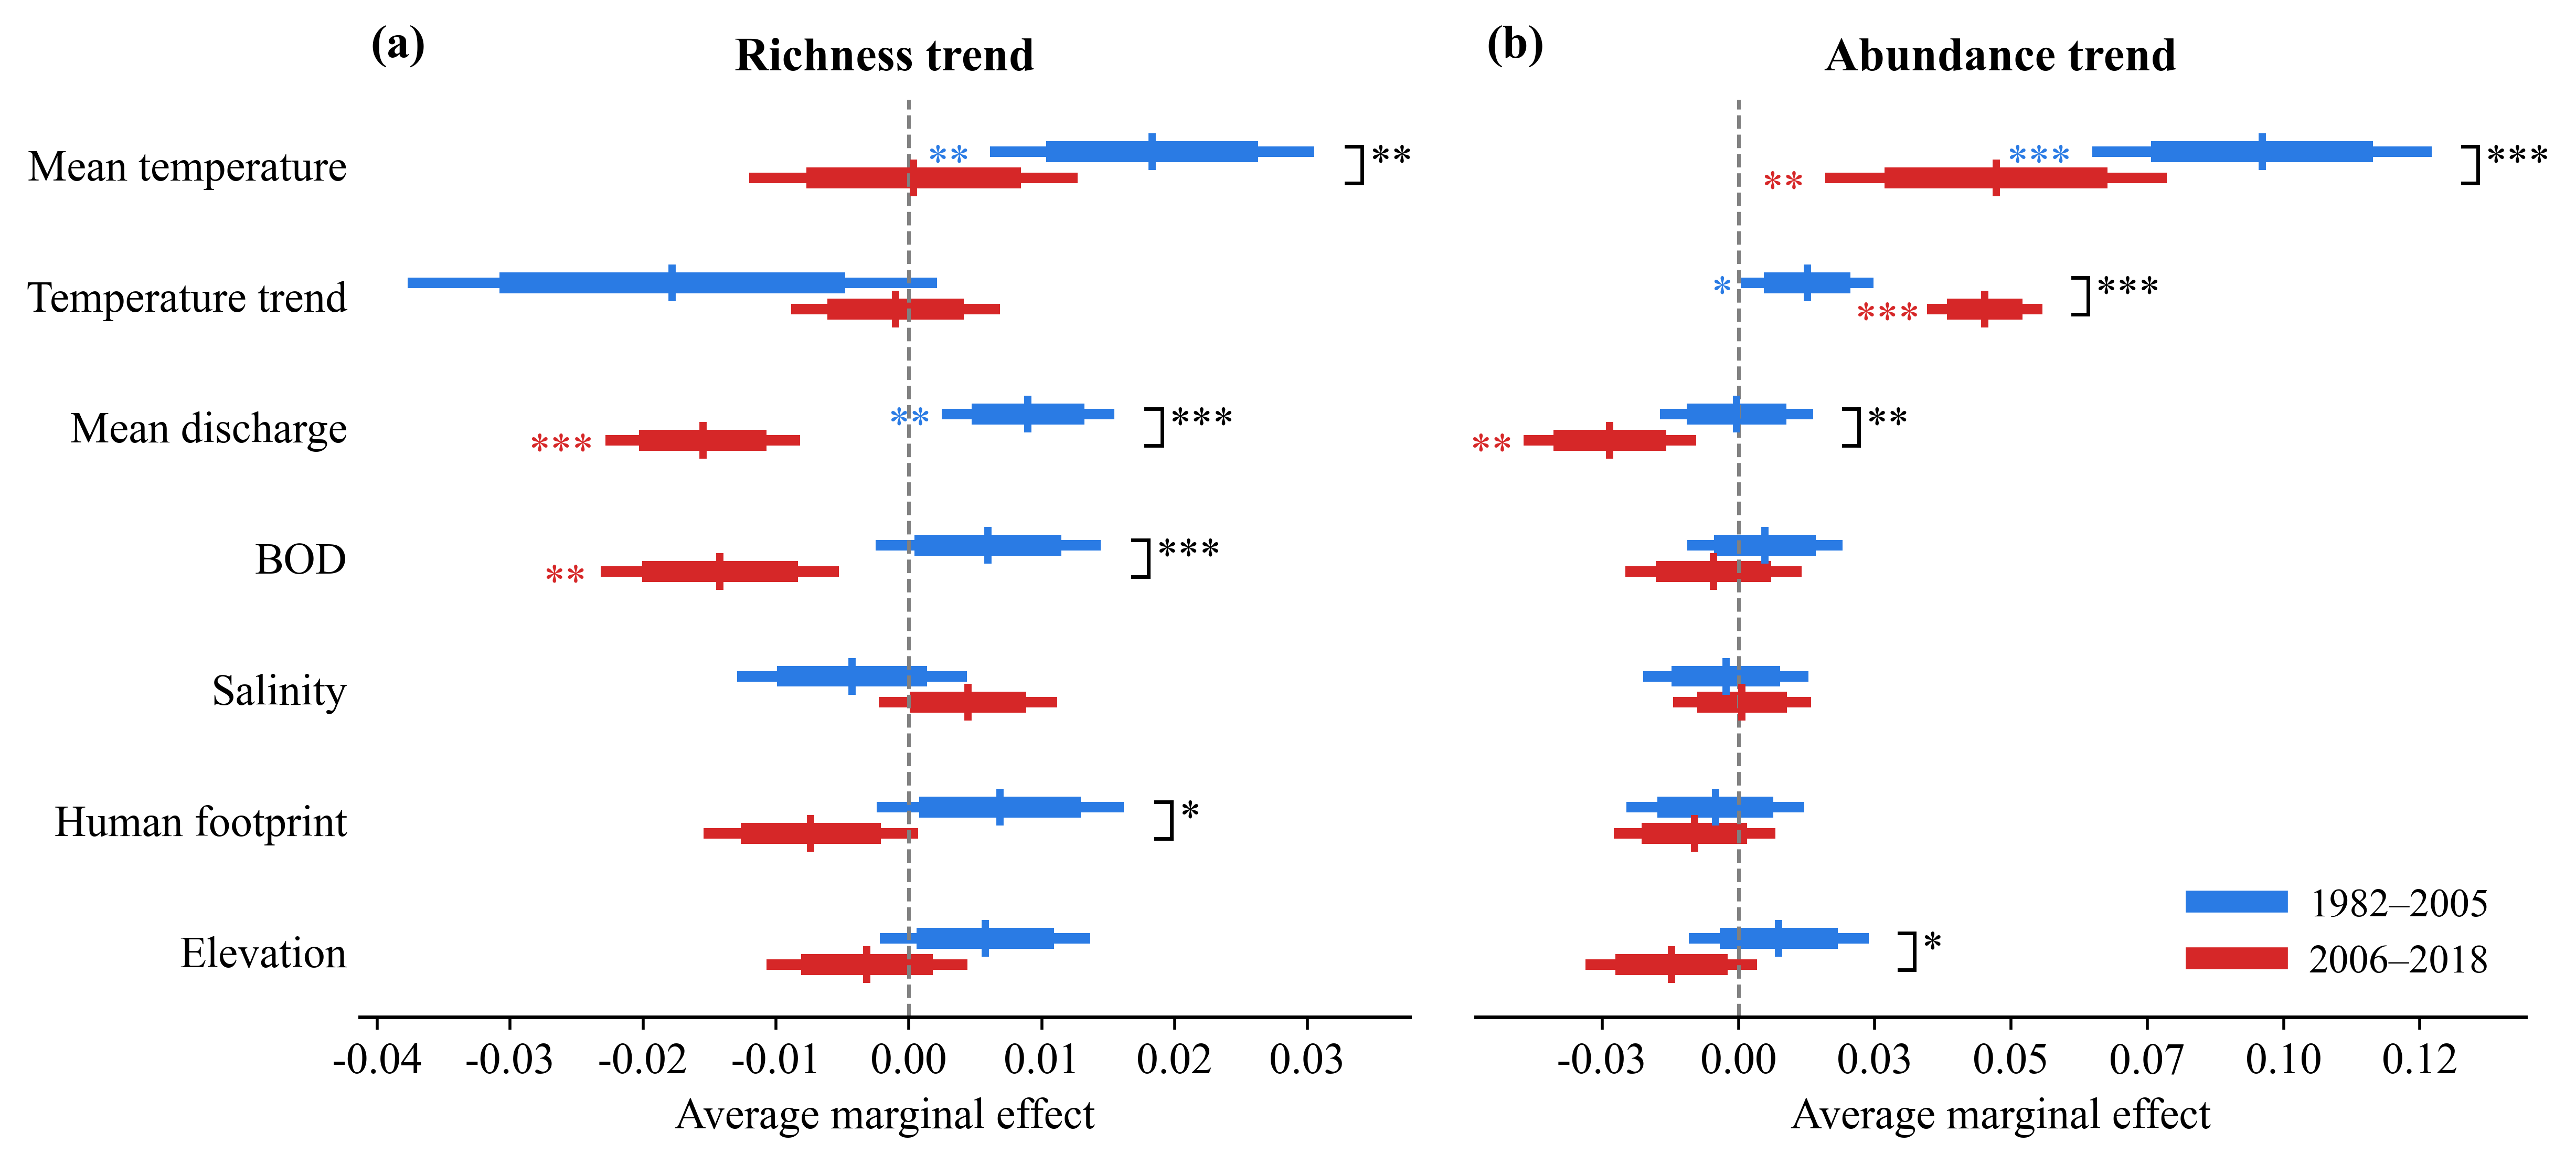

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

df_rich = pd.read_csv(
    r"D:\paper\outputdata\Phase-specific modelling of 2005\Period_MarginalEffects_All.csv"
)

df_abun = pd.read_csv(
    r"D:\paper\outputdata\Phase-specific modelling of 2005\Period_effects_All_Abundance_AME.csv"
)
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.linewidth": 1,
    "font.size": 12
})

EARLY_COLOR = "#2a7be4"
LATE_COLOR  = "#d62728"

W95 = 0.08
W80 = 0.16
Y_OFFSET = 0.10

Z95 = 1.96
Z80 = 1.28

order_vars = [
    "mean_temp",
    "sen_temp",
    "mean_Q",
    "mean_organic",
    "mean_salinity",
    "HFP_period",
    "elevation"
]

name_map = {
    "mean_temp":     "Mean temperature",
    "sen_temp":      "Temperature trend",
    "mean_Q":        "Mean discharge",
    "mean_organic":  "BOD",
    "mean_salinity": "Salinity",
    "HFP_period":    "Human footprint",
    "elevation":     "Elevation",
}

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

def plot_all_panel(ax, df_effects, panel_label, title):

    sub_z = df_effects[df_effects["Zone"] == "All"]

    vals = np.abs(sub_z[
        ["Early_CI95_L", "Early_CI95_U",
         "Late_CI95_L",  "Late_CI95_U"]
    ].values.flatten())

    M = max(np.round(vals.max() + 0.015, 2), 0.06)

    for i, v in enumerate(order_vars):
        y0 = i
        sub_v = sub_z[sub_z["Factor"] == v]
        if sub_v.empty:
            continue
        for eff, lo95, up95, dy, color, pval in [
            (sub_v["Early_Effect"].values[0],
             sub_v["Early_CI95_L"].values[0],
             sub_v["Early_CI95_U"].values[0],
             -Y_OFFSET, EARLY_COLOR,
             sub_v["Early_p"].values[0]),

            (sub_v["Late_Effect"].values[0],
             sub_v["Late_CI95_L"].values[0],
             sub_v["Late_CI95_U"].values[0],
             +Y_OFFSET, LATE_COLOR,
             sub_v["Late_p"].values[0])
        ]:

            yy = y0 + dy

            se = (up95 - eff) / Z95
            lo80 = eff - Z80 * se
            up80 = eff + Z80 * se
            ax.add_patch(Rectangle(
                (lo95, yy - W95/2),
                up95 - lo95, W95,
                facecolor=color, linewidth=0
            ))
            ax.add_patch(Rectangle(
                (lo80, yy - W80/2),
                up80 - lo80, W80,
                facecolor=color, linewidth=0
            ))
            ax.plot(
                eff, yy, marker="|",
                color=color,
                markersize=10,
                markeredgewidth=2,
                zorder=10
            )
            ax.text(
                lo95 - 0.06*(up95 - lo95),
                yy + 0.1,
                p_to_star(pval),
                color=color,
                ha="right",
                va="center",
                fontsize=12
            )

        p_delta = sub_v["Delta_p"].values[0]
        star_d = p_to_star(p_delta)

        if star_d:
            xmax = max(
                sub_v["Early_CI95_U"].values[0],
                sub_v["Late_CI95_U"].values[0]
            )
            dx = 0.03 * (2 * M)

            ax.plot(
                [xmax + dx, xmax + dx],
                [y0 - Y_OFFSET - W95/2, y0 + Y_OFFSET + W95/2],
                color="black", lw=1
            )
            ax.plot(
                [xmax + dx - 0.01*(2*M), xmax + dx],
                [y0 - Y_OFFSET - W95/2]*2,
                color="black", lw=1
            )
            ax.plot(
                [xmax + dx - 0.01*(2*M), xmax + dx],
                [y0 + Y_OFFSET + W95/2]*2,
                color="black", lw=1
            )

            ax.text(
                xmax + dx * 1.15,
                y0,
                star_d,
                va="center",
                ha="left",
                fontsize=12
            )
    ax.axvline(0, color="gray", linestyle="--", lw=1)
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.text(
        0.01, 1.08, panel_label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top",
        ha="left"
    )

    ax.set_xlabel("Average marginal effect", fontsize=12)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", length=0)

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4.6),
    dpi=500,
    sharey=True
)

plot_all_panel(
    axes[0], df_rich,
    panel_label="(a)",
    title="Richness trend"
)

plot_all_panel(
    axes[1], df_abun,
    panel_label="(b)",
    title="Abundance trend"
)

axes[0].set_yticks(np.arange(len(order_vars)))
axes[0].set_yticklabels([name_map[v] for v in order_vars])
axes[0].invert_yaxis()
legend_elems = [
    Line2D([0], [0], color=EARLY_COLOR, lw=6, label="1982–2005"),
    Line2D([0], [0], color=LATE_COLOR,  lw=6, label="2006–2018"),
]

axes[1].legend(
    handles=legend_elems,
    loc="lower right",
    frameon=False,
    fontsize=11
)
plt.tight_layout()
plt.savefig(
    r"C:\Users\Lenovo\Desktop\extendFig11.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()